In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
from torch import nn
from torch.nn import functional as F
import copy

import sys
import os
import pathlib
import pickle
import itertools
from typing import Callable

from omegaconf import OmegaConf

In [25]:
sys.path.append(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src')

import data_preparation
import models_gnn
import model_loader
import losses
import run_experiment

In [3]:
device = torch.device('cpu')

if torch.cuda.is_available():
    device = torch.device('cuda')

device

device(type='cuda')

In [4]:
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\sym_no_reg\neighbors_init\dump_neighbors_init_seed_269_adj_269.bin')
print(f"{path=}")

with open(path, 'rb') as f:
    target_run_info = pickle.load(f)

path=WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps/sym_no_reg/neighbors_init/dump_neighbors_init_seed_269_adj_269.bin')


In [5]:
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\sym_no_reg\random_init\dump_random_init_seed_269_adj_4615.bin')
print(f"{path=}")

with open(path, 'rb') as f:
    random_run_info = pickle.load(f)

path=WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps/sym_no_reg/random_init/dump_random_init_seed_269_adj_4615.bin')


<Axes: >

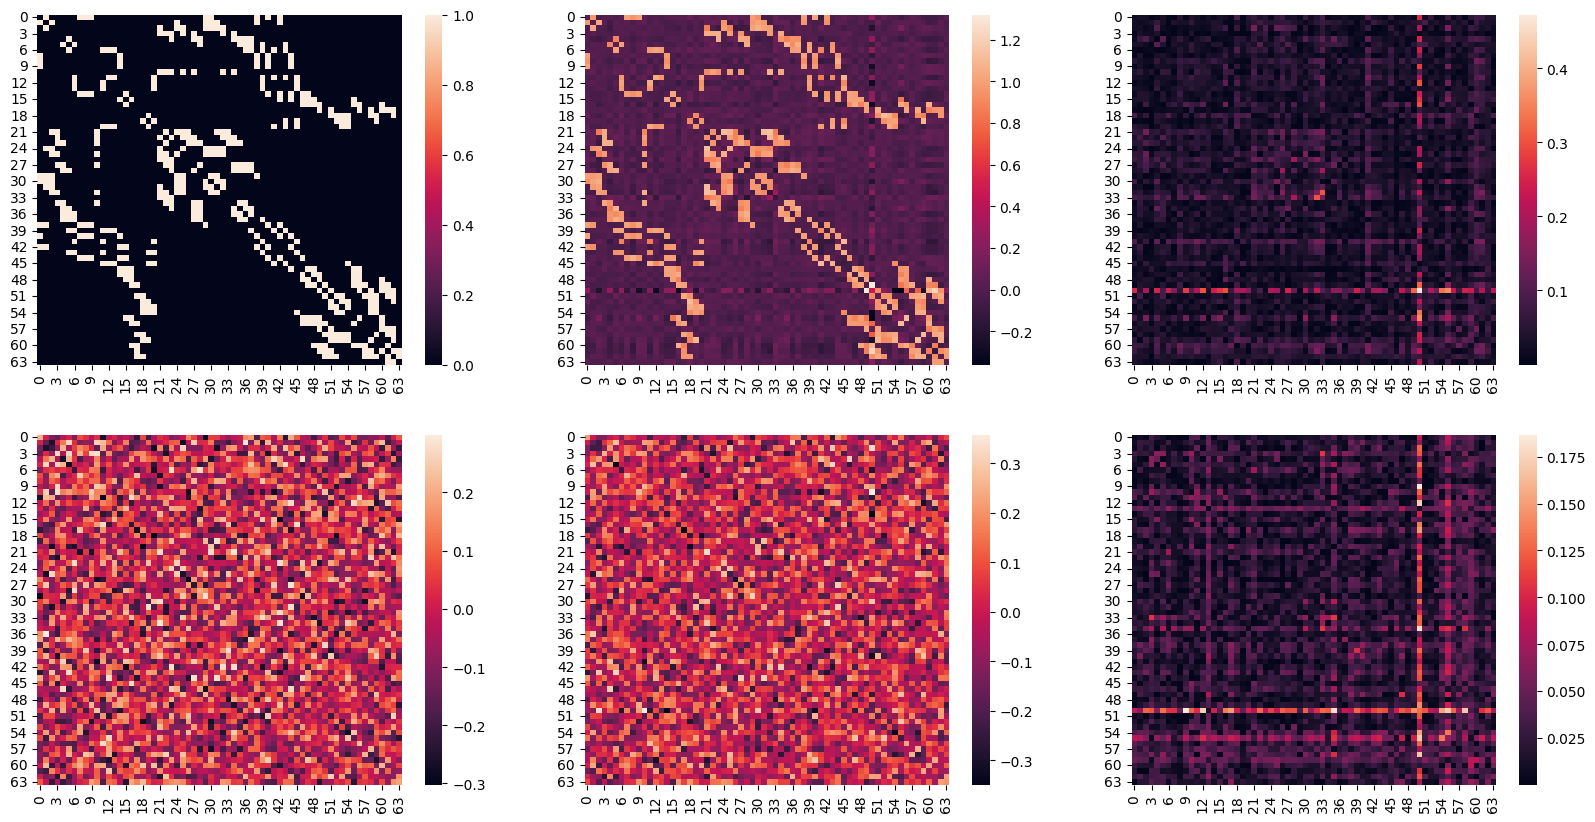

In [6]:
_, ax = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))

adj_init = target_run_info['adj']['init']
adj_final = target_run_info['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[0, 0])
sns.heatmap(adj_final, ax=ax[0, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[0, 2])


adj_init = random_run_info['adj']['init']
adj_final = random_run_info['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[1, 0])
sns.heatmap(adj_final, ax=ax[1, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[1, 2])

In [7]:
def adj_conv(adj_1: torch.Tensor, adj_2: torch.Tensor) -> Callable:
    def conv(theta: float) -> torch.Tensor:
        return adj_2 * theta + adj_1 * (1.0 -  theta)
    
    return conv

In [8]:
cfg_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\configs\viewer_cfg.yaml'
cfg = OmegaConf.load(cfg_path) 

train_res = run_experiment.run(cfg_path)

tensor([42,  0,  0,  ...,  0,  0,  0], dtype=torch.uint8)


  0%|          | 0/85 [00:00<?, ?it/s]C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
  4%|▎         | 3/85 [00:00<00:02, 29.59it/s]C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarn

val/loss: 0.43177777777777776	val/epoch_acc: 0.5682222222222222	val/epoch_bc: 0.4948	val/epoch_ones: 416.47058823529414	val/epoch_precision: 0.16299435028248588	val/epoch_recall: 0.38466666666666666	val/epoch_f1: 0.22896825396825402	val/TP: 1154	val/TN: 9074	val/FP: 5926	val/FN: 1846



  0%|          | 0/200 [00:00<?, ?it/s]

train/loss: 0.2596783279718137	train/epoch_acc: 0.5004313725490196	train/epoch_bc: 0.5004313725490196	train/epoch_ones: 311.2448979591837	train/epoch_precision: 0.500360632089699	train/epoch_recall: 0.5985098039215686	train/epoch_f1: 0.5450519624299132	train/TP: 7631	train/TN: 5130	train/FP: 7620	train/FN: 5119



...

val/loss: 0.22089906141493054	val/epoch_acc: 0.6481666666666667	val/epoch_bc: 0.6138333333333333	val/epoch_ones: 394.52941176470586	val/epoch_precision: 0.25152825406291934	val/epoch_recall: 0.5623333333333334	val/epoch_f1: 0.34758421757494595	val/TP: 1687	val/TN: 9980	val/FP: 5020	val/FN: 1313

train/loss: 0.2018864315257353	train/epoch_acc: 0.7016078431372549	train/epoch_bc: 0.7016078431372549	train/epoch_ones: 264.14285714285717	train/epoch_precision: 0.6986015606891757	train/epoch_recall: 0.7091764705882353	train/epoch_f1: 0.7038492974740203	train/TP: 9042	train/TN: 8849	train/FP: 3901	train/FN: 3708



100%|█████████▉| 199/200 [05:15<00:01,  1.45s/it]

val/loss: 0.22460757107204862	val/epoch_acc: 0.6413333333333333	val/epoch_bc: 0.6155999999999999	val/epoch_ones: 406.94117647058823	val/epoch_precision: 0.2502168256721596	val/epoch_recall: 0.577	val/epoch_f1: 0.3490623109497883	val/TP: 1731	val/TN: 9813	val/FP: 5187	val/FN: 1269

train/loss: 0.20186278339460784	train/epoch_acc: 0.699764705882353	train/epoch_bc: 0.6997647058823528	train/epoch_ones: 266.57142857142856	train/epoch_precision: 0.6949931097841066	train/epoch_recall: 0.712	train/epoch_f1: 0.703393770339377	train/TP: 9078	train/TN: 8766	train/FP: 3984	train/FN: 3672



100%|██████████| 200/200 [05:16<00:00,  1.58s/it]

val/loss: 0.22124888780381943	val/epoch_acc: 0.647	val/epoch_bc: 0.6127333333333334	val/epoch_ones: 395.4117647058824	val/epoch_precision: 0.2505206783695329	val/epoch_recall: 0.5613333333333334	val/epoch_f1: 0.3464307755605842	val/TP: 1684	val/TN: 9962	val/FP: 5038	val/FN: 1316

train_stats=defaultdict(<function train_model.<locals>.<lambda> at 0x000002656A345800>, {'TP': [7631, 8343, 8852, 8617, 8093, 7843, 8001, 7913, 7986, 8119, 8186, 8089, 8113, 8246, 8336, 8344, 8309, 8470, 8390, 8447, 8524, 8405, 8470, 8463, 8496, 8543, 8451, 8571, 8546, 8522, 8517, 8578, 8608, 8591, 8652, 8625, 8607, 8687, 8669, 8648, 8661, 8673, 8687, 8661, 8680, 8594, 8734, 8673, 8692, 8580, 8709, 8732, 8673, 8705, 8736, 8731, 8679, 8751, 8663, 8730, 8740, 8761, 8716, 8690, 8726, 8704, 8758, 8743, 8773, 8748, 8735, 8728, 8765, 8729, 8823, 8704, 8799, 8781, 8739, 8801, 8760, 8820, 8737, 8827, 8749, 8802, 8841, 8813, 8756, 8806, 8819, 8819, 8831, 8779, 8813, 8803, 8896, 8805, 8833, 8900, 8799, 8896, 8812, 8823,

In [9]:
base_nn = copy.deepcopy(train_res['model'])

base_nn

BaseGNN(
  (gc): SmallGIN(
    (adj): AdjLayer()
    (h): Linear(in_features=48, out_features=48, bias=True)
  )
  (linear_channel): Conv1d(64, 1, kernel_size=(1,), stride=(1,))
  (conv): Conv1d(1, 1, kernel_size=(13,), stride=(1,), padding=same)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (hook): ReLU(inplace=True)
  (linear_output): Linear(in_features=48, out_features=2, bias=True)
  (sig): Softmax(dim=1)
)

In [10]:
def get_nn(base_nn, adj_matrix):
    if isinstance(adj_matrix, np.ndarray):
        adj_matrix = torch.from_numpy(adj_matrix)

    adj_layer = models_gnn.AdjLayer(
        n_channels=cfg.n_channels, 
        init_mat=adj_matrix,
        is_sym=cfg.adj_sym
    )

    base_nn.gc.adj = adj_layer

    return base_nn

In [29]:
@torch.inference_mode
def score_model(model: nn.Module, dataloader: torch.utils.data.DataLoader, criterion: losses.HybridLoss):
    model.eval()
    running_TP, running_TN, running_FP, running_FN = 0, 0, 0, 0
    running_loss = 0.0
    num_objs = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        inputs_size = inputs.size(0)

        outputs = model(inputs)
        loss = criterion(input=outputs, target=labels, adj=model.gc.adj.adj_mat)

        _, preds = torch.max(outputs, 1)
        _, true_y = torch.max(labels.data, 1)

        P = torch.sum(preds)
        N = torch.sum(1 - preds)
        TP = torch.sum(torch.masked_select(true_y, preds == 1))
        TN = torch.sum(torch.masked_select(1 - true_y, preds == 0))
        FP = P - TP
        FN = N - TN

        running_loss += loss.item() * inputs_size
        running_TP += TP.item()
        running_TN += TN.item()
        running_FP += FP.item()
        running_FN += FN.item()
        num_objs += inputs_size

    running_loss = running_loss / num_objs

    return {
        'loss': running_loss,
        'TP': running_TP,
        'TN': running_TN,
        'FP': running_FP,
        'FN': running_FN,
    }

In [30]:
def calc_accuracy(TP: int, TN: int, FP: int, FN: int, **kwargs):
    return (TP + TN) / (TP + TN + FP + FN)

def calc_recall(TP: int, TN: int, FP: int, FN: int, **kwargs):
    return TP / (TP + FN)

def calc_precision(TP: int, TN: int, FP: int, FN: int, **kwargs):
    return TP / (TP + FP)

def calc_f1(TP: int, TN: int, FP: int, FN: int, **kwargs):
    precision = calc_precision(TP=TP, TN=TN, FP=FP, FN=FN)
    recall = calc_recall(TP=TP, TN=TN, FP=FP, FN=FN)

    f1 = 2 * precision * recall / (precision + recall)

    return f1

In [31]:
base_nn.gc.adj.adj_mat

Parameter containing:
tensor([[ 0.0175,  0.9726, -0.0236,  ..., -0.0721, -0.0375,  0.0404],
        [ 0.9726,  0.0167,  1.0236,  ..., -0.0398,  0.0347, -0.0257],
        [-0.0236,  1.0236, -0.0078,  ...,  0.0246,  0.0358, -0.0129],
        ...,
        [-0.0721, -0.0398,  0.0246,  ..., -0.1261,  0.9196,  0.9824],
        [-0.0375,  0.0347,  0.0358,  ...,  0.9196,  0.0386,  0.9823],
        [ 0.0404, -0.0257, -0.0129,  ...,  0.9824,  0.9823,  0.0318]],
       device='cuda:0', requires_grad=True)

In [32]:
# base_nn = get_nn(base_nn, adj_matrix=random_run_info['adj']['init'])
# base_nn = get_nn(base_nn, adj_matrix=target_run_info['adj']['init'])

# base_nn.gc.adj.adj_mat

In [15]:
train_dataset, test_dataset = data_preparation.load_dataset(cfg)
_, test_dataloader = data_preparation.get_dataloaders(cfg, train_dataset, test_dataset)

  0%|          | 0/85 [00:00<?, ?it/s]C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
  5%|▍         | 4/85 [00:00<00:02, 38.20it/s]C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarn

In [ ]:
mid_model = get_nn(base_nn, adj_matrix=random_run_info['adj']['final']).to(device)
criterion = model_loader.load_criterion(cfg)
scores = score_model(mid_model, test_dataloader, criterion)

f1 = calc_f1(**scores)
accuracy = calc_accuracy(**scores)

print(scores)
print(f"{f1=}\t{accuracy=}")

{'loss': 0.24925573632452222, 'TP': 1134, 'TN': 9962, 'FP': 5038, 'FN': 1866}
f1=0.247274313126908	accuracy=0.6164444444444445


In [34]:
mid_model = get_nn(base_nn, adj_matrix=target_run_info['adj']['final']).to(device)
scores = score_model(mid_model, test_dataloader, criterion)

f1 = calc_f1(**scores)
accuracy = calc_accuracy(**scores)

print(scores)
print(f"{f1=}\t{accuracy=}")

{'loss': 0.33019215750694275, 'TP': 908, 'TN': 10018, 'FP': 4982, 'FN': 2092}
f1=0.2042744656917885	accuracy=0.607


In [45]:
adj_geodetic = adj_conv(
    # adj_1=random_run_info['adj']['final'],
    adj_1=train_res['logs']['adj']['final'],
    adj_2=target_run_info['adj']['final']
)
criterion = model_loader.load_criterion(cfg)

thetas = np.linspace(0.0, 1.0, num=500)

f1_ls = np.zeros_like(thetas)
acc_ls = np.zeros_like(thetas)
loss_ls = np.zeros_like(thetas)

for i, theta in enumerate(thetas):
    adj_mat = adj_geodetic(theta)
    mid_model = get_nn(base_nn, adj_matrix=adj_mat).to(device)

    scores = score_model(mid_model, test_dataloader, criterion)
    f1 = calc_f1(**scores)
    accuracy = calc_accuracy(**scores)

    f1_ls[i] = f1
    acc_ls[i] = accuracy
    loss_ls[i] = scores['loss']

Text(0, 0.5, 'Loss')

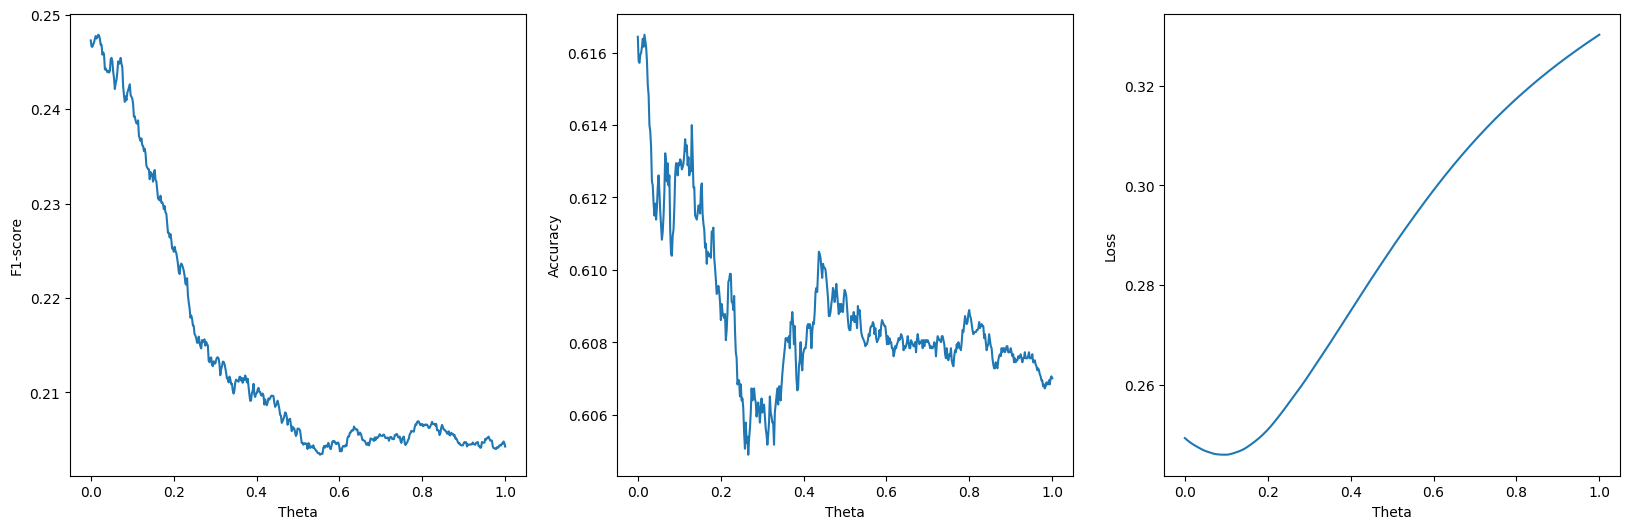

In [41]:
_, ax = plt.subplots(ncols=3, figsize=(20, 6))

ax[0].plot(thetas, f1_ls)
ax[0].set_xlabel('Theta')
ax[0].set_ylabel('F1-score')

ax[1].plot(thetas, acc_ls)
ax[1].set_xlabel('Theta')
ax[1].set_ylabel('Accuracy')

ax[2].plot(thetas, loss_ls)
ax[2].set_xlabel('Theta')
ax[2].set_ylabel('Loss')

Text(0, 0.5, 'Loss')

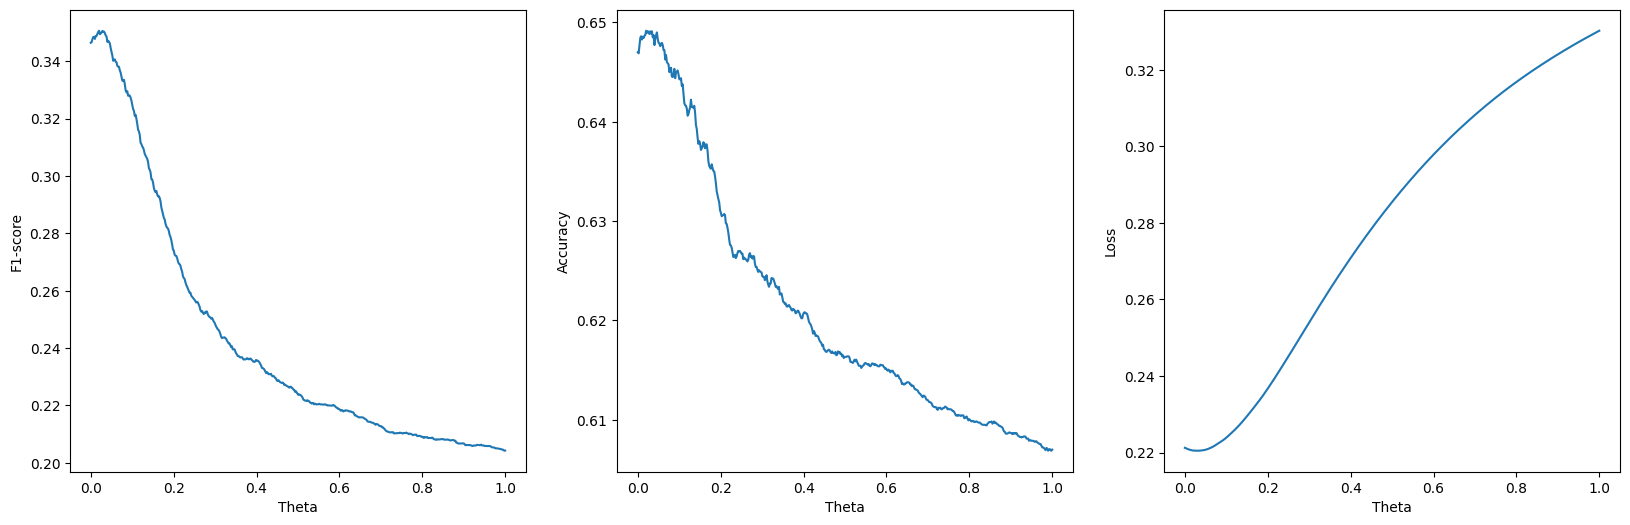

In [46]:
_, ax = plt.subplots(ncols=3, figsize=(20, 6))

ax[0].plot(thetas, f1_ls)
ax[0].set_xlabel('Theta')
ax[0].set_ylabel('F1-score')

ax[1].plot(thetas, acc_ls)
ax[1].set_xlabel('Theta')
ax[1].set_ylabel('Accuracy')

ax[2].plot(thetas, loss_ls)
ax[2].set_xlabel('Theta')
ax[2].set_ylabel('Loss')